In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *

from scipy.signal import find_peaks

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


In [2]:

def load_file_one_go(files, chunk_size, baseline_window_ns, channel):
    prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    subtract_baseline=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None, 
    high_limit_mV=None, 
    margin_mV=0.0,
    max_saturated_samples=0,
    channel=channel,
    time_origin='zero',
    )
    time_ns = prerocessed_data["time_ns"]
    voltage_mV = prerocessed_data["voltage_mV"]

    preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in ['is_saturated', 'n_saturated_samples']}
    preprocessed_event_info.update({ 
        'event_file': prerocessed_data['event_file'],
        'event_segment': prerocessed_data['event_segment']
    })

    df = build_waveform_feature_dataframe(
        time_ns,
        voltage_mV,
        peak_threshold_mV=None,
        second_peak_min_height_frac=0.2,
        pre_peak_ns = 20,
        post_peak_ns = 80,
        pre_rise_ns = 10, 
        post_rise_ns = 80, 
        extra=preprocessed_event_info 
    )
    cutflow = CutFlow(len(df))

    cutflow.apply( "peaks in the baseline", reject_baseline_pulses( df, baseline_window_ns, min_peak_height_mV=0.5 ) )
    cutflow.print()

    df_sel = df[cutflow.mask].copy()
    waveforms_sel = voltage_mV[cutflow.mask]

    return time_ns, waveforms_sel, df_sel


# Select Files


In [3]:
channel="Channel 2"
data_dir = Path("data/WA0089/LED_sweep/260625/850V_525MHz")

# file_name = "led_080"
file_name = "led_100"
# file_name = "led_120"

# Set to a number for quick iteration, or None to use all matching files.
max_files = 2

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")

# save
save_plots = False
save_dir = 'plots_selection'
# file_nickname = '' 

data/WA0089/LED_sweep/260625/850V_525MHz/led_100-1.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-10.h5
Number of files loaded: 2


In [4]:
chunk_size = 512 #4096
# baseline_window_width_ns          = 20
baseline_window_ns                = (0, 20)
selection_peak_threshold_max_mV   = 0.5

In [5]:
time_ns ,waveforms_mV, df =  load_file_one_go(files, chunk_size, baseline_window_ns, channel)


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31006      100.0%        100.0%
peaks in the baseline         30990       99.9%         99.9%


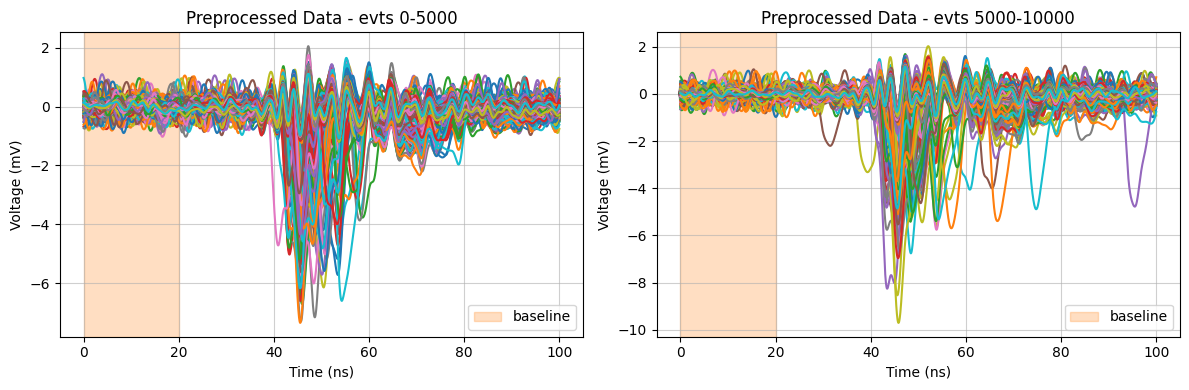

In [6]:
n_to_plot = 5000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

add_plot_waveforms(axes[0], time_ns, waveforms_mV[:n_to_plot], title=f"Preprocessed Data - evts 0-{n_to_plot}")
axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[0].legend(loc="lower right")

add_plot_waveforms(axes[1], time_ns, waveforms_mV[n_to_plot:2*n_to_plot], title=f"Preprocessed Data - evts {n_to_plot}-{2*n_to_plot}")
axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[1].legend(loc="lower right")

fig.tight_layout()
# save_plot(fig, save_plots, save_dir, file_nickname,"few_waveforms", Nevents=n_to_plot);

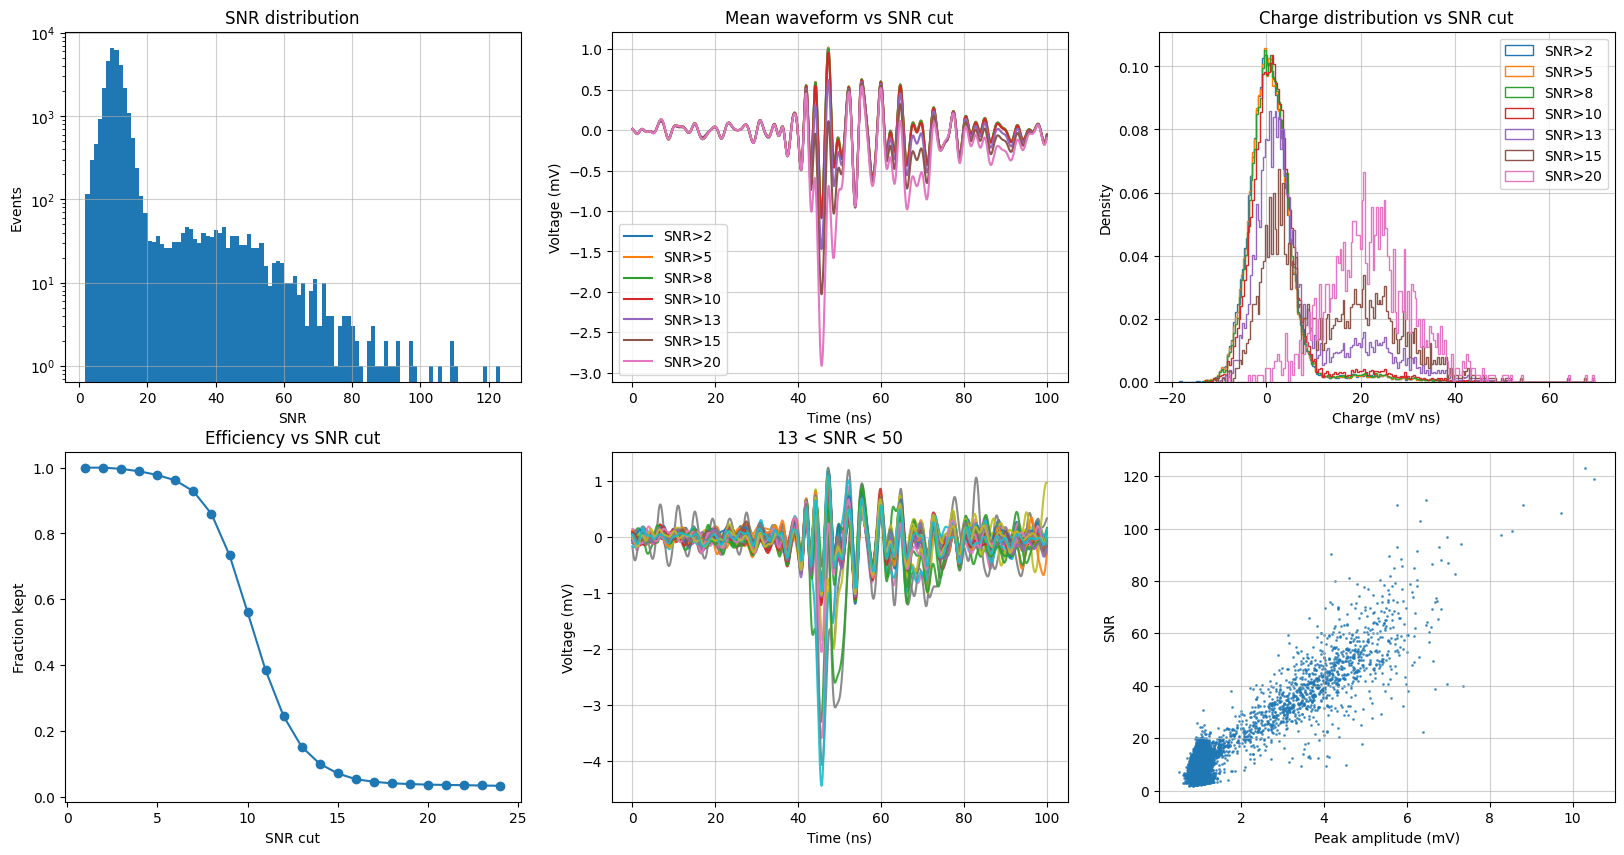

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()
plot_snr_distribution(axes[0], df)
plot_mean_waveforms_vs_snr(axes[1], df, waveforms_mV, time_ns, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_charge_histograms_vs_snr(axes[2], df, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_snr_efficiency(axes[3], df, cuts=np.arange(1, 25))
plot_waveforms_in_snr_range( axes[4],  df, waveforms_mV, time_ns, snr_min=13, snr_max=50, n_waveforms=50)  
plot_snr_vs_amplitude(axes[5], df)  
# save_plot(fig, save_plots, save_dir, file_nickname, f"snr_repport",  Nevents=None)

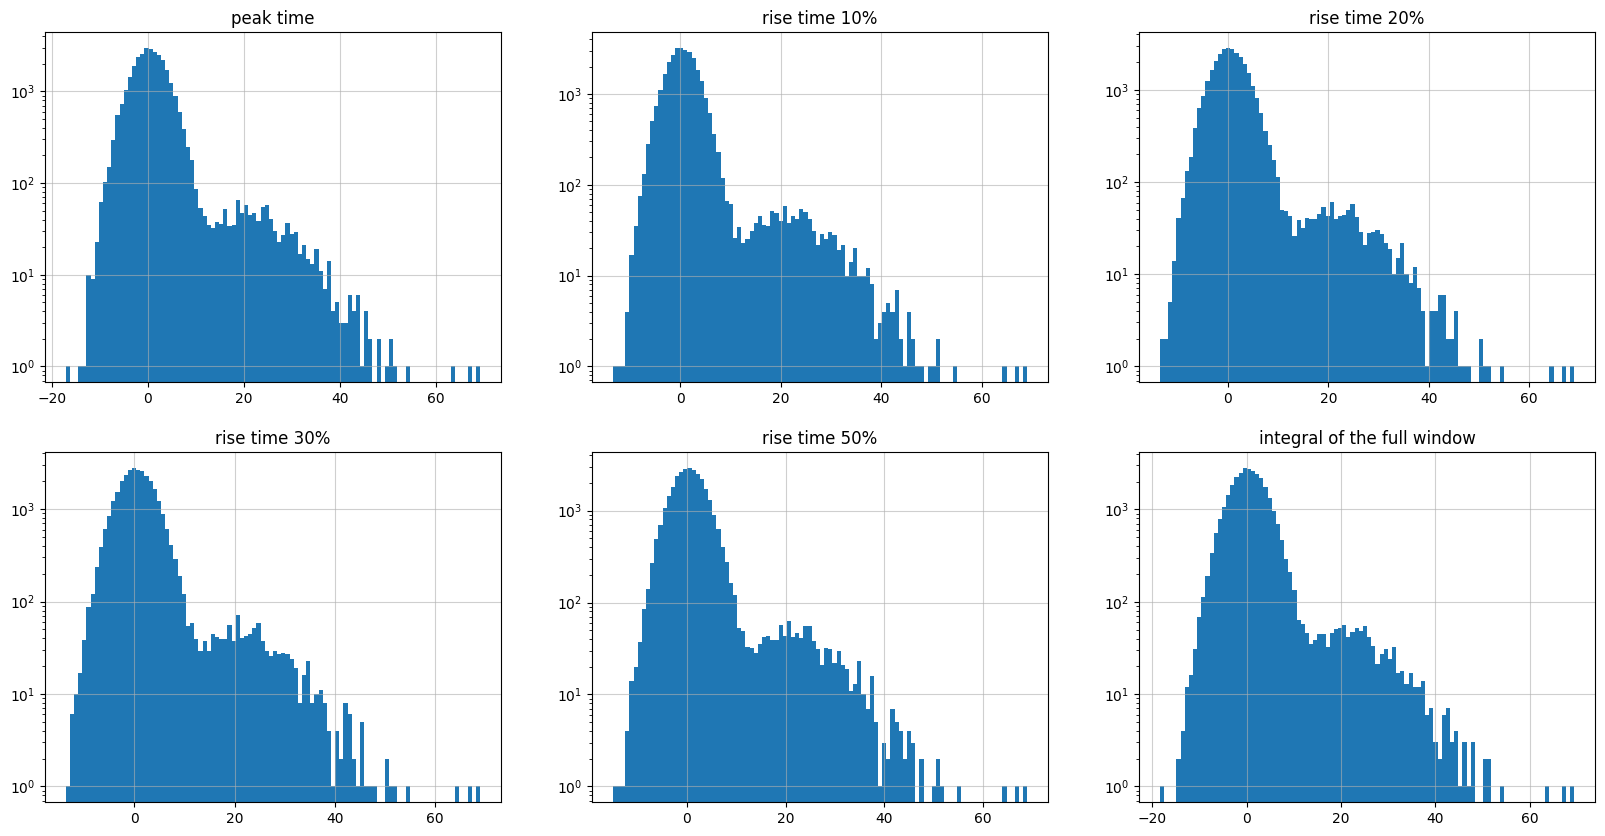

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

rg = None #(-20, 10)

axes[0].hist(df.charge_peak_window_mV_ns, bins=100, range=rg);
axes[0].set_title("peak time")
axes[1].hist(df.charge_cfd10_window_mV_ns, bins=100, range=rg);
axes[1].set_title("rise time 10%");
axes[2].hist(df.charge_cfd20_window_mV_ns, bins=100, range=rg);
axes[2].set_title("rise time 20%");
axes[3].hist(df.charge_cfd30_window_mV_ns, bins=100, range=rg);
axes[3].set_title("rise time 30%");
axes[4].hist(df.charge_cfd50_window_mV_ns, bins=100, range=rg);
axes[4].set_title("rise time 50%");
axes[5].hist(df.area_mV_ns, bins=100, range=rg);
axes[5].set_title("integral of the full window");

for i in range(0, 6):
    axes[i].set_yscale('log')


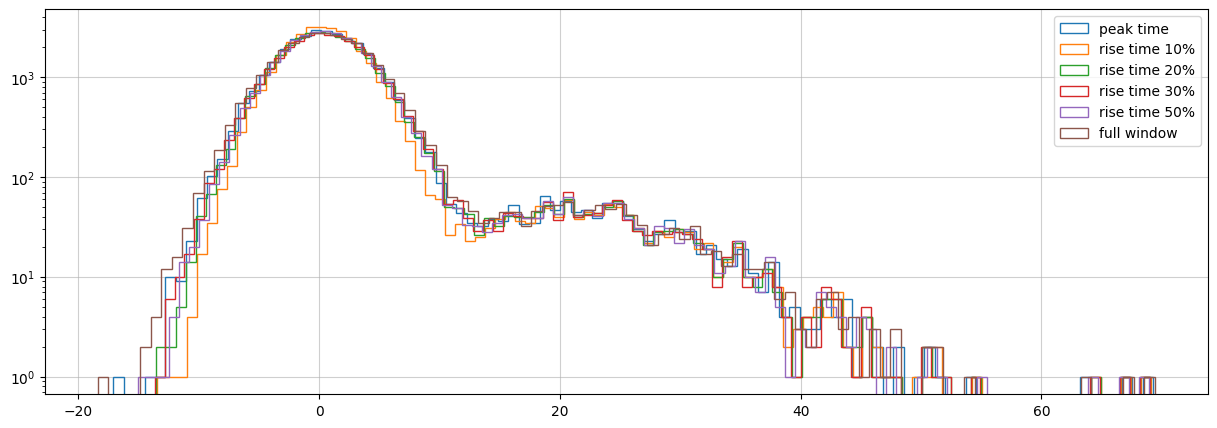

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))


rg = None #(-20, 10)
den=False

axes.hist(df.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.legend();

# save_plot(fig, save_plots, save_dir, file_nickname, f"charge_all_methods",  Nevents=None)

